In [16]:
import pandas as pd

df = pd.read_csv(r"C:\Users\amank\Downloads\Housing.csv")



In [15]:
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [19]:
print(df.shape)

(545, 13)


In [20]:
target = df["price"]      # Target variable (what we want to predict)
features = df.drop("price", axis=1)  # All other columns are features

In [21]:
print("Target column:")
print(target.head())

print("\nFeature columns:")
print(features.columns)

Target column:
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

Feature columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [22]:
print(df.isnull().sum())


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [23]:
df.fillna(0)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [24]:
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]
Index: []


In [25]:
print(df.select_dtypes(include='object').columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [27]:
# Check correlation with price
corr = df_encoded.corr()

# Correlation of all features with price
price_corr = corr['price'].sort_values(ascending=False)

print(price_corr)


price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [28]:
selected_features = price_corr[abs(price_corr) > 0.1].index

# Create new dataset with selected features
df_selected = df_encoded[selected_features]

print(df_selected.columns)
print(df_selected.shape)

Index(['price', 'area', 'bathrooms', 'airconditioning_yes', 'stories',
       'parking', 'bedrooms', 'prefarea_yes', 'mainroad_yes', 'guestroom_yes',
       'basement_yes', 'furnishingstatus_unfurnished'],
      dtype='object')
(545, 12)


In [29]:
X = df_selected.drop('price', axis=1)
y = df_selected['price']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (545, 11)
Target: (545,)


In [30]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_selected.drop('price', axis=1)
y = df_selected['price']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (436, 11)
X_test shape: (109, 11)
y_train shape: (436,)
y_test shape: (109,)


In [31]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coefficients)

Intercept: 173403.89791160822
                         Feature   Coefficient
0                           area  2.369369e+02
1                      bathrooms  1.106159e+06
2            airconditioning_yes  7.443175e+05
3                        stories  4.243053e+05
4                        parking  2.423348e+05
5                       bedrooms  7.583559e+04
6                   prefarea_yes  6.135216e+05
7                   mainroad_yes  3.662417e+05
8                  guestroom_yes  2.253204e+05
9                   basement_yes  4.065224e+05
10  furnishingstatus_unfurnished -3.420444e+05


In [33]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[5242415.58175574 7150315.39828818 3179006.19049428 4650923.98677992
 3235886.82745876 3547788.22555442 5545306.02336564 6331596.31090557
 2748825.79183368 2571104.69836985]


In [34]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0       4060000     5.242416e+06
1       6650000     7.150315e+06
2       3710000     3.179006e+06
3       6440000     4.650924e+06
4       2800000     3.235887e+06
5       4900000     3.547788e+06
6       5250000     5.545306e+06
7       4543000     6.331596e+06
8       2450000     2.748826e+06
9       3353000     2.571105e+06


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 983524.3526229819
MSE : 1800615616273.5293
RMSE: 1341870.193526009
R² Score: 0.6437648447817457


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1046022.2417431193
MSE : 2009963714568.8672
RMSE: 1417731.8909331437
R² Score: 0.6023472586979222


In [39]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression": [983524.35, 1341870.19, 0.6438],
    "Random Forest": [rf_mae, rf_rmse, rf_r2]
})

print(comparison)

     Metric  Linear Regression  Random Forest
0       MAE       9.835243e+05   1.046022e+06
1      RMSE       1.341870e+06   1.417732e+06
2  R² Score       6.438000e-01   6.023473e-01


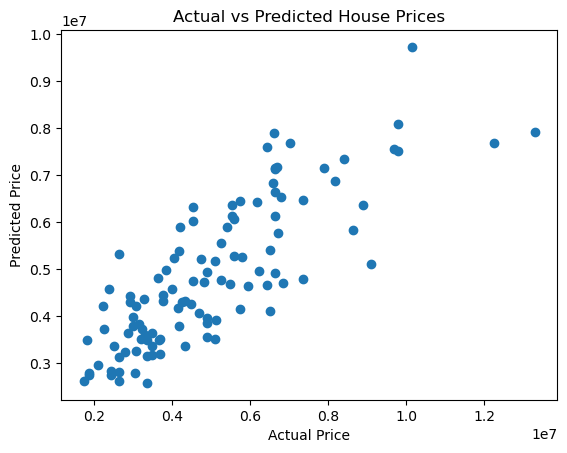

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

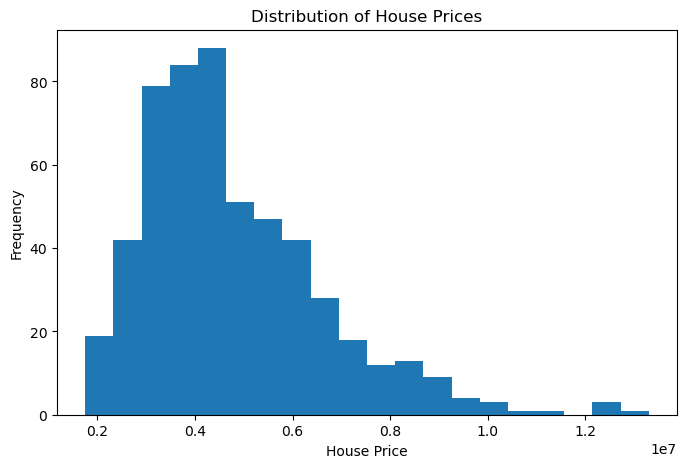

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

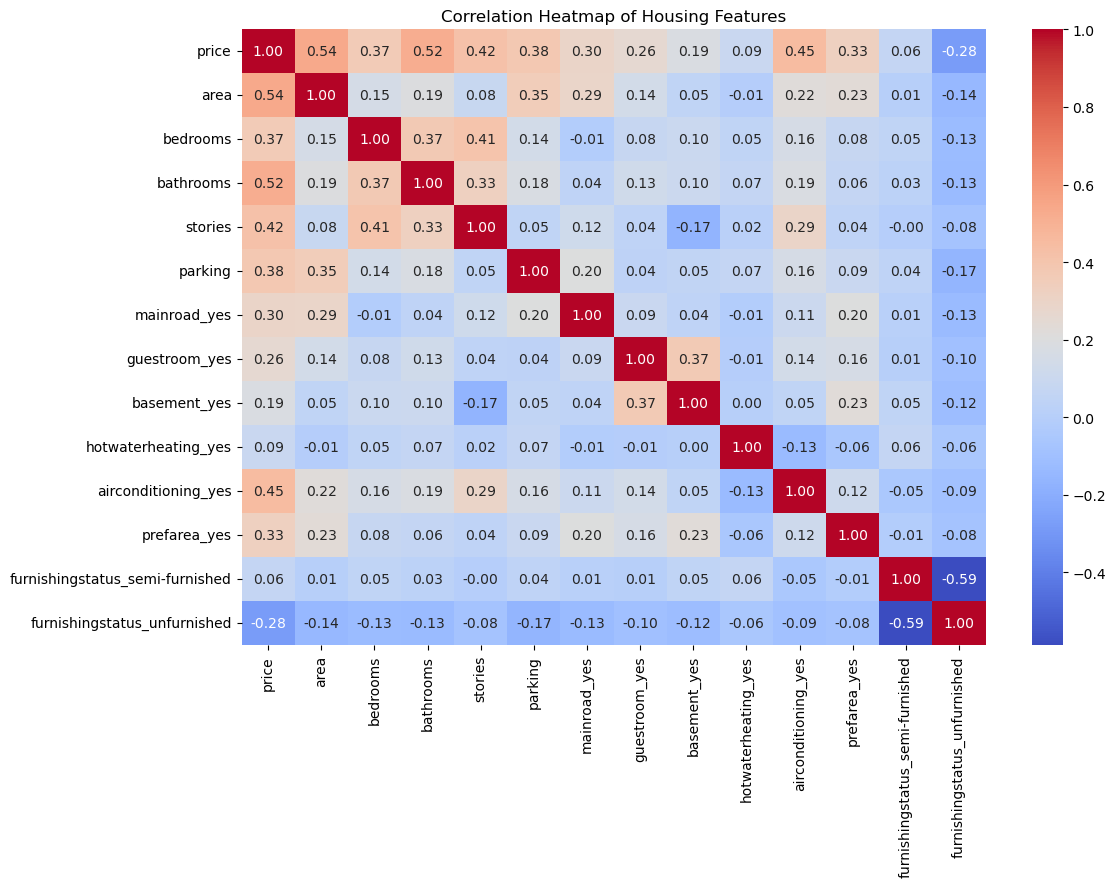

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Housing Features")
plt.show()

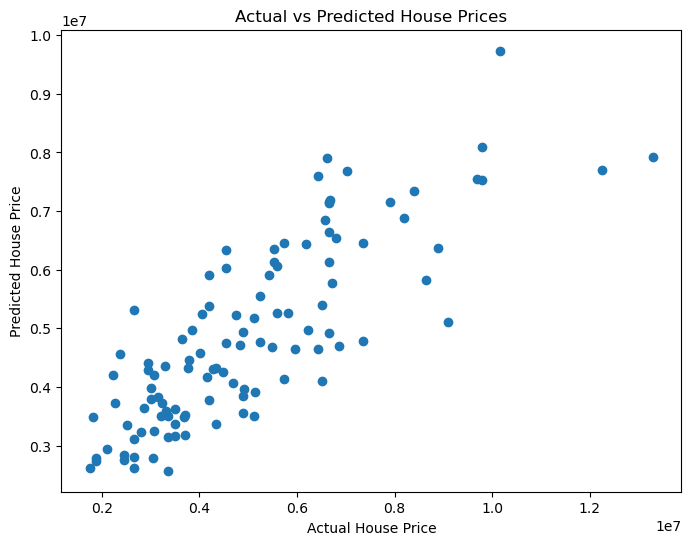

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()



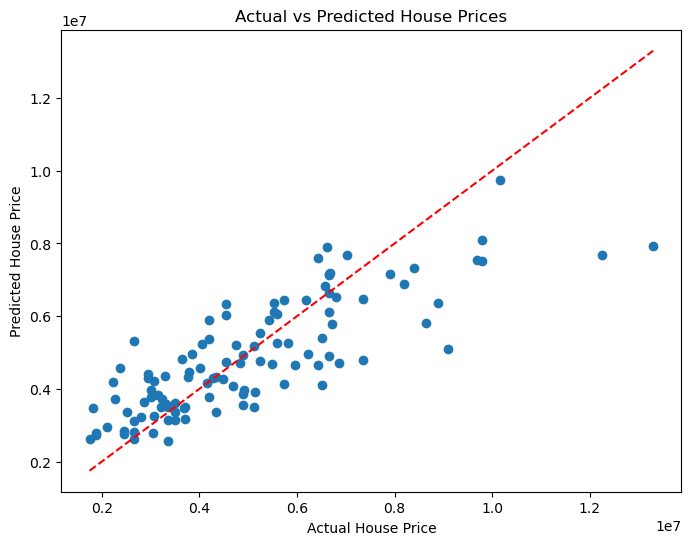

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

# INSIGHTS AND SUMMARY

In [ ]:
The analysis showed that house price is most strongly influenced by factors such as area, number of bathrooms, number of stories, parking availability, and air conditioning. The Linear Regression model achieved an R² score of 0.64, meaning it was able to explain about 64% of the variation in house prices. In simple terms, the model provided reasonably accurate predictions but still made some errors, with an average prediction error of around ₹9.8 lakh. One surprising finding was that certain amenities such as air conditioning and preferred location had a noticeable impact on price, sometimes more than expected. The data also showed that larger houses generally command significantly higher prices. Based on these findings, a real estate business should focus on properties with larger areas, modern amenities, and good locations, as these features contribute most to higher property values and better returns.
